In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

from helpers import *

device: cuda


In [2]:
%load_ext autoreload
%autoreload 2

### load network

In [3]:
%cd ../..

/home/fusiontomo/Repos/diffusion_tomography


In [4]:
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

missing keys: 0
unexpected keys: 0


### prior sampling

Prior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

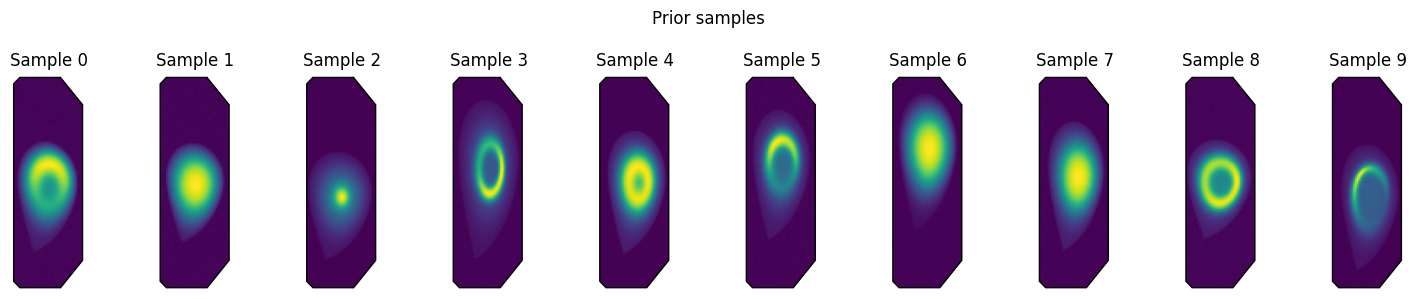

In [5]:
H, W = 120, 40
prior_samples, diffusion_process = sample_prior(
    model=model,
    schedule=schedule,
    image_shape=(1, H, W),
    num_samples=99,
    num_inference_steps=250,   # increase to 1000 for full schedule
    eta=0.0,                   # 0: deterministic DDIM, >0: more stochastic
    clip_range=None,
)
show_samples(prior_samples[:10], ncols=10, title="Prior samples", figsize=(15,3))

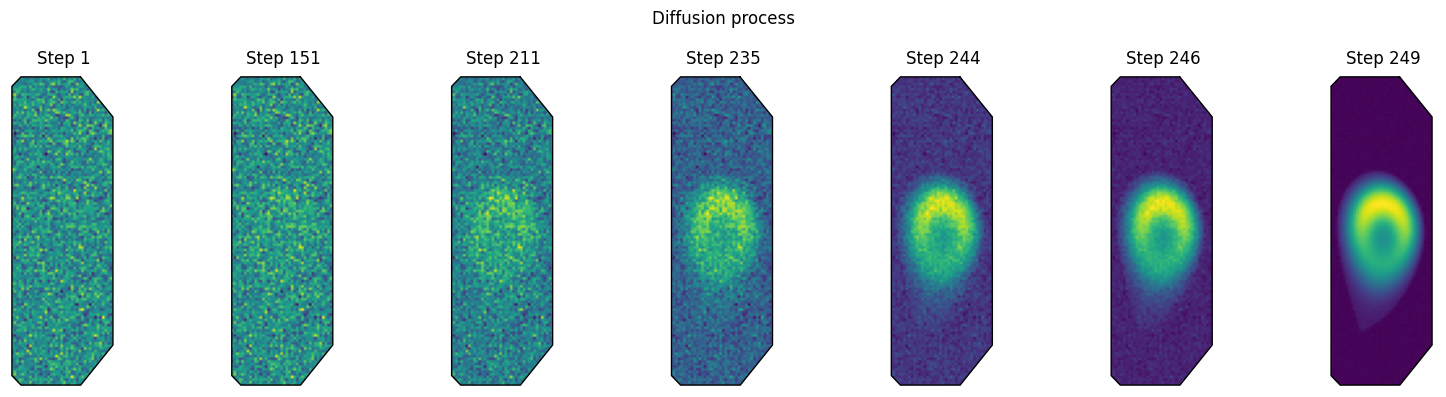

<Figure size 300x300 with 0 Axes>

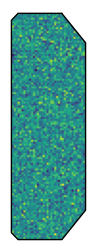

<Figure size 300x300 with 0 Axes>

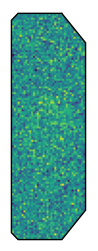

<Figure size 300x300 with 0 Axes>

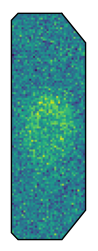

<Figure size 300x300 with 0 Axes>

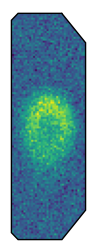

<Figure size 300x300 with 0 Axes>

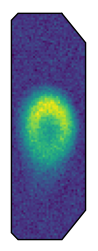

<Figure size 300x300 with 0 Axes>

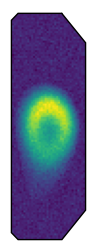

<Figure size 300x300 with 0 Axes>

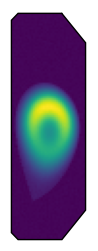

In [6]:
L = len(diffusion_process)
indices = [1, 151, 211, 235, 244, 246, 249]
dp_tensor = torch.stack([diffusion_process[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=len(indices),
    figsize=(16, 4),
    title="Diffusion process", 
)

#save each individual eps figure
for i, idx in enumerate(indices):
    plt.figure(figsize=(3,3))
    tomo_plots.plot_profile(np.array(dp_tensor[i][0].cpu()), tcv_plot_clip=True,
                                contour_image=None, cmap="viridis", ax=None,
                                colorbar=False, contour_color="w",
                                aspect=None, lcfs_width=1, lwidth=0.2)
    plt.axis('off')
    plt.savefig(f'results_images/prior_sampling_process/figs/diffusion_process_step_{idx}_{i}.eps', format='eps', bbox_inches="tight")